# Notebook 03 — Análisis Exploratorio de Datos (EDA)
## Proyecto Integrador | Minería de Datos I
**Integrantes:** Valeria Martinetti y Santiago Gallardo

**Dataset:** `streaming_users_clean.csv` — salida del pipeline de limpieza (`02_calidad_y_limpieza.ipynb`)

---
### Preguntas que surgen de la inspección (`01_inspeccion_inicial.ipynb`)

1. ¿Cómo se distribuye el tiempo de visualización mensual de los usuarios y cuáles son sus principales características estadísticas?
2. ¿Cómo se distribuye la edad de los usuarios y qué características presenta esta variable?
3. ¿Cómo se distribuye el tiempo de visualización mensual según el plan de suscripción?
4. ¿Existe relación entre la edad y los minutos de visualización mensual?
5. ¿Existen diferencias en la cantidad promedio de tickets de soporte entre los distintos países y planes de suscripción?


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/processed/streaming_users_clean.csv',
                  parse_dates=['last_login_date'])

ORDEN_PLAN = ['Básico', 'Estándar', 'Premium']
PALETA_PLAN = {'Básico': '#4e79a7', 'Estándar': '#f28e2b', 'Premium': '#59a14f'}

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dataset cargado: 8034 filas × 8 columnas


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,Estándar,805.8,Brasil,Otros,2025-03-04,1.0
1,10001,37.0,Estándar,1173.4,Colombia,Otros,2019-04-02,2.0
2,10002,28.0,Básico,401.0,Colombia,Otros,2018-04-13,0.0
3,10003,43.0,Básico,62.4,Uruguay,Thriller,2021-01-31,0.0
4,10004,51.0,Básico,477.8,Perú,Thriller,2020-09-30,1.0


---
## 1. Análisis Univariado

**Visualización 1** — Distribución del tiempo de visualización mensual (`monthly_watch_time_mins`)

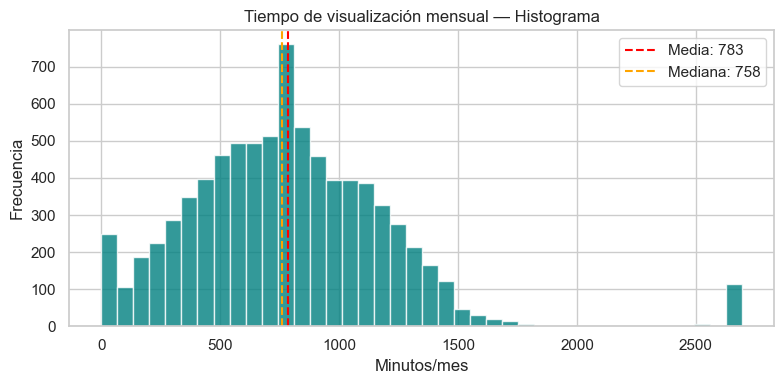

count    8034.0
mean      782.7
std       427.8
min         0.0
25%       499.7
50%       758.5
75%      1029.2
max      2693.4
Name: monthly_watch_time_mins, dtype: float64
Asimetría: 1.196


In [65]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['monthly_watch_time_mins'], bins=40, color='teal', edgecolor='white', alpha=0.8)

media = df['monthly_watch_time_mins'].mean()
mediana = df['monthly_watch_time_mins'].median()

ax.axvline(media, color='red', linestyle='--', lw=1.5, label=f"Media: {media:.0f}")
ax.axvline(mediana, color='orange', linestyle='--', lw=1.5, label=f"Mediana: {mediana:.0f}")
ax.set_xlabel('Minutos/mes')
ax.set_ylabel('Frecuencia')
ax.set_title('Tiempo de visualización mensual — Histograma')
ax.legend()

plt.tight_layout()
plt.show()

desc = df['monthly_watch_time_mins'].describe()
print(desc.round(1))
print(f"Asimetría: {df['monthly_watch_time_mins'].skew():.3f}")

El tiempo de visualización mensual tiene asimetría positiva moderada, con media≈783 min por encima de la mediana ≈759 min, hay una cola de usuarios con alto consumo. El 50% central se ubica entre ≈500 y ≈1.029 minutos/mes, 8 a 17 horas. El máximo quedó acotado en ≈2.693 min por la winsorización (k=3) aplicada en la
limpieza, que eliminó el valor centinela 99.999 sin destruir el patrón real de los usuarios de
mayor consumo. Esta distribución es la base sobre la que se apoya la Pregunta 1, que se responde
en detalle en la sección bivariada.

**Visualización 2** — Distribución de la edad

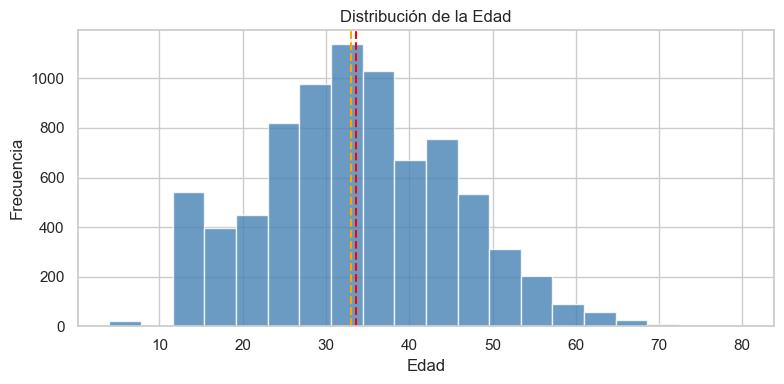

count    8034.000000
mean       33.613020
std        11.563183
min         4.000000
25%        25.000000
50%        33.000000
75%        41.000000
max        80.000000
Name: age, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(8,4))

# Histograma

ax.hist(df['age'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)

media = df['age'].mean()
mediana = df['age'].median()

ax.axvline(media, color='red', linestyle='--', lw=1.5, label=f"Media: {media:.0f}")
ax.axvline(mediana, color='orange', linestyle='--', lw=1.5, label=f"Mediana: {mediana:.0f}")

ax.set_title("Distribución de la Edad")
ax.set_xlabel("Edad")
ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(df['age'].describe())

La edad promedio de usuarios es 33 años.


---
## 2. Análisis Bivariado

**Visualización 3** — Tiempo de visualización según plan de suscripción.

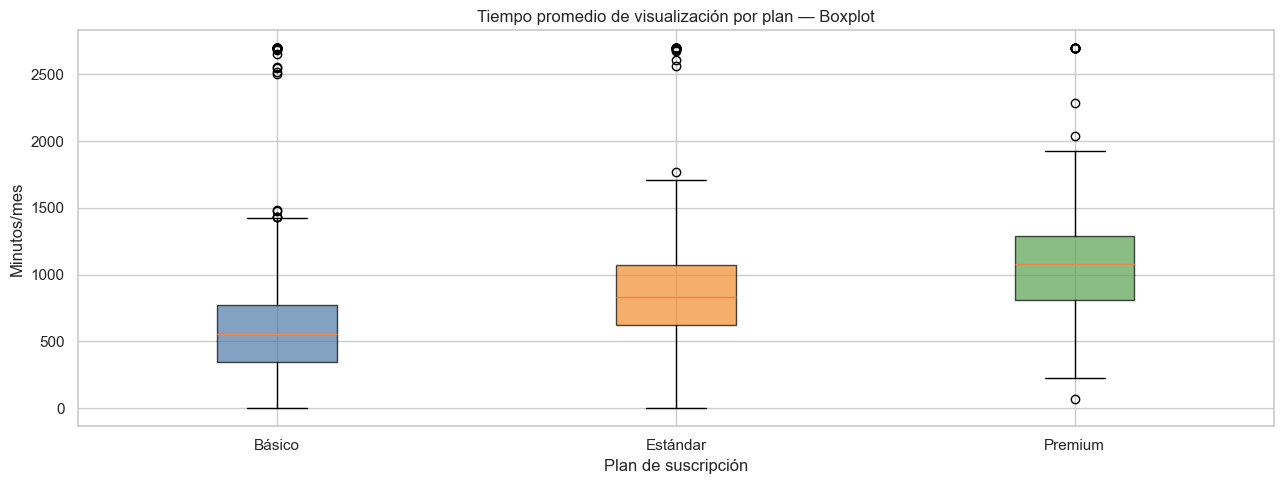

Básico: media=589 min | mediana=557 min | n=3609
Estándar: media=860 min | mediana=834 min | n=2833
Premium: media=1085 min | mediana=1081 min | n=1592


In [62]:
fig, ax = plt.subplots(figsize=(13, 5))

data_por_plan = [df.loc[df['subscription_plan'] == p, 'monthly_watch_time_mins'] for p in ORDEN_PLAN]
bp = ax.boxplot(data_por_plan, patch_artist=True, labels=ORDEN_PLAN)
for patch, plan in zip(bp['boxes'], ORDEN_PLAN):
    patch.set_facecolor(PALETA_PLAN[plan])
    patch.set_alpha(0.7)
ax.set_title('Tiempo promedio de visualización por plan — Boxplot')
ax.set_xlabel('Plan de suscripción')
ax.set_ylabel('Minutos/mes')

plt.tight_layout()
plt.show()

for plan in ORDEN_PLAN:
    g = df.loc[df['subscription_plan'] == plan, 'monthly_watch_time_mins']
    print(f"{plan}: media={g.mean():.0f} min | mediana={g.median():.0f} min | n={len(g)}")

El plan de suscripción es un diferenciador claro del consumo. Los usuarios **Premium** visualizan en promedio **1.085 min/mes**, los **Estándar** **860 min/mes** y los **Básico** **589 min/mes**. Hay una brecha Premium–Básico, y las cajas del boxplot casi no se superponen, lo que indica una separación consistente y no solo un efecto de outliers. El patrón es coherente con la idea de que el plan más caro atrae o genera usuarios de mayor consumo.

**Visualización 4** — Relación entre edad y tiempo de visualización.

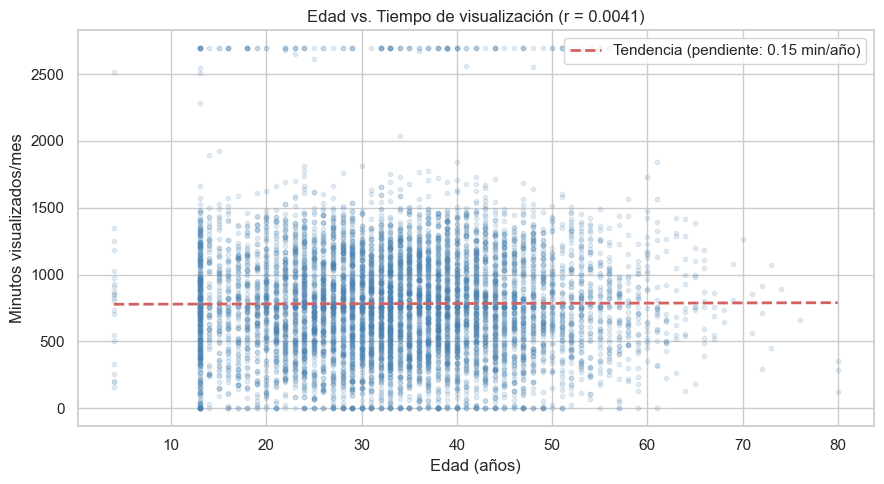

Correlación de Pearson: 0.0041


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['age'], df['monthly_watch_time_mins'], alpha=0.15, s=10, color='steelblue')

z = np.polyfit(df['age'], df['monthly_watch_time_mins'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['age'].min(), df['age'].max(), 100)
corr = df[['age', 'monthly_watch_time_mins']].corr().iloc[0, 1]
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Tendencia (pendiente: {z[0]:.2f} min/año)')

ax.set_xlabel('Edad (años)')
ax.set_ylabel('Minutos visualizados/mes')
ax.set_title(f'Edad vs. Tiempo de visualización (r = {corr:.4f})')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Correlación de Pearson: {corr:.4f}")

La correlación entre edad y tiempo de visualización es prácticamente nula y la línea de tendencia es casi horizontal. La edad no predice el consumo de contenido: usuarios jóvenes y mayores presentan niveles de visualización similares.
Esto refuerza el hallazgo de la Visualización 3, el plan de suscripción explica el consumo, no la
edad del usuario.

---
## 3. Análisis Multivariado

**Visualización 5** — Plan de suscripción por pais y tickets de soporte promedio.


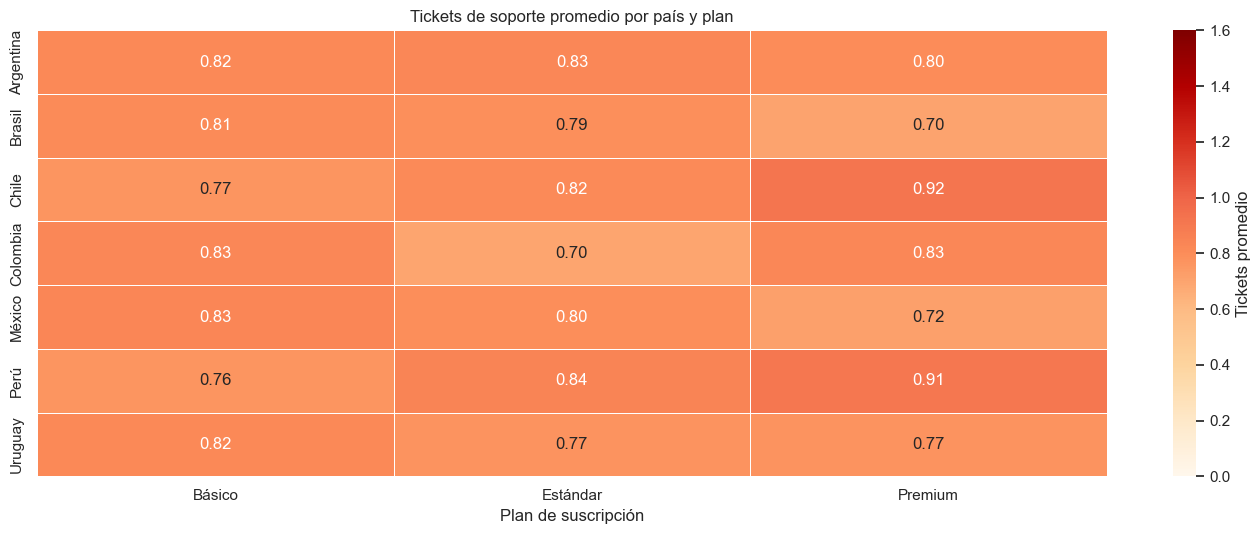

Tickets promedio por país y plan:
subscription_plan  Básico  Estándar  Premium
country                                     
Argentina           0.824     0.828    0.802
Brasil              0.808     0.789    0.703
Chile               0.769     0.817    0.920
Colombia            0.825     0.699    0.826
México              0.832     0.799    0.717
Perú                0.765     0.844    0.909
Uruguay             0.821     0.771    0.774


In [64]:
fig, ax = plt.subplots(figsize=(14, 5.5))

# Panel derecho: tickets de soporte promedio por país y plan
tickets_pais_plan = df_geo.groupby(['country', 'subscription_plan'])['customer_support_tickets'] \
                          .mean().unstack().reindex(columns=ORDEN_PLAN)

sns.heatmap(tickets_pais_plan, annot=True, fmt='.2f', cmap='OrRd', ax=ax,
            vmin=0, vmax=1.6, cbar_kws={'label': 'Tickets promedio'}, linewidths=0.5)
ax.set_title('Tickets de soporte promedio por país y plan')
ax.set_xlabel('Plan de suscripción')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

print('Tickets promedio por país y plan:')
print(tickets_pais_plan.round(3))

Se puede observar que los tickets de soporte no están asociados de forma relevante ni al plan ni al país.
Estas actúan como variables independientes de los tickets de soporte.

---
## Síntesis de hallazgos del EDA

| # | Pregunta | Respuesta (visualización/tabla) |
|---|---|---|
| 1 | Tiempo de visualizacion según plan | El consumo mensual difiere entre los planes de suscripción. El boxplot muestra la distribución, la mediana y los valores atípicos de cada plan (Viz. 3)|
| 2 | Edad vs. watch time | La correlación entre la edad y el tiempo de visualización es practicamente nula, por lo que la edad no resulta un buen predictor del consumo mensual (Viz. 4) |
| 3 | Tickets por país y plan | El heatmap compara el promedio de tickets por país y plan, permitiendo identificar diferencias entre las distintas combinaciones (Viz. 5) |
| 4 | Distribución del watch time | El histograma y las estadísticas descriptivas muestran una distribución concentrada alrededor de la media, junto con la dispersión y la posible presencia de valores atípicos (Viz. 1) |
| 5 | Tickets vs. plan/país | El análisis del heatmap permite evaluar si existen asociaciones entre el país, el plan de suscripción y la cantidad promedio de tickets de soporte (Viz. 5) |
